使用デバイス: cuda
モデルの重みを読み込みました。

テストデータ全件の評価を開始します... (Top-K: 160)
評価が完了しました。

定量評価結果 (Top-160 パッチ)
[SSIM 異常検知] 閾値: 0.825
 - ACC  : 93.98%
 - PREC : 96.77%
 - REC  : 95.24%
 - F1   : 96.00%
----------------------------------------
[MSE 異常検知] 閾値: 0.08
 - ACC  : 75.90%
 - PREC : 97.78%
 - REC  : 69.84%
 - F1   : 81.48%



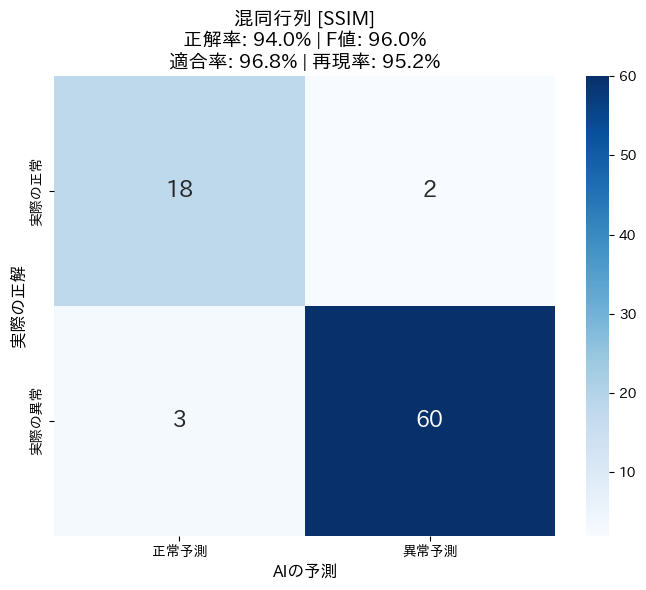

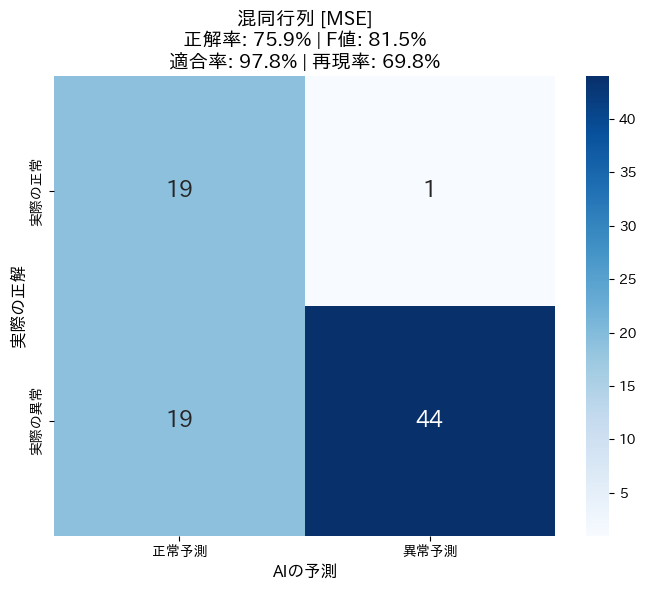

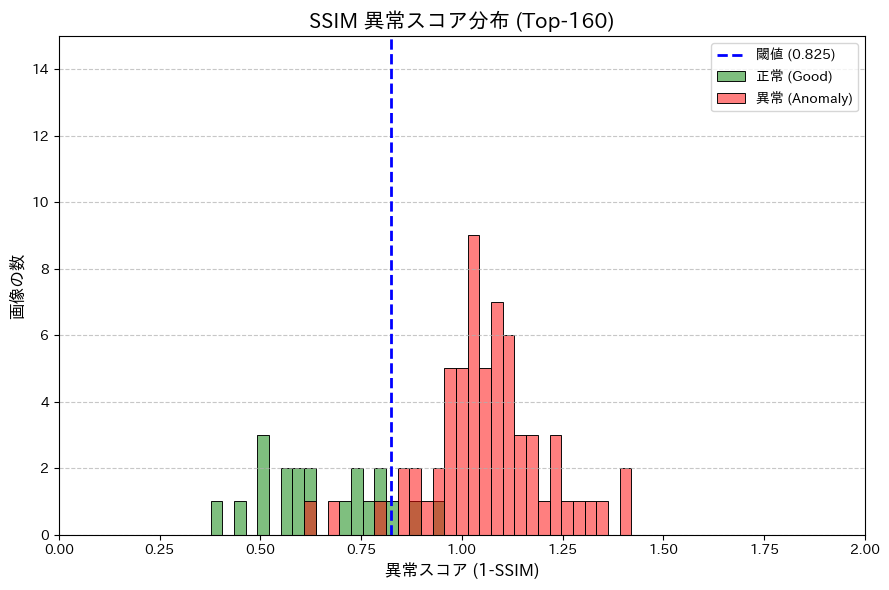

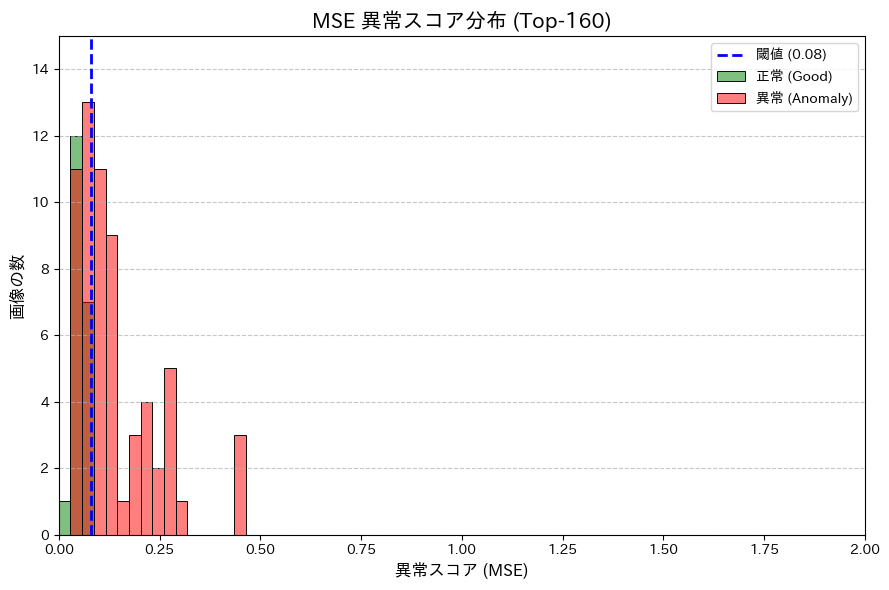


--- ランダムに数枚抽出し、SSIMとMSEのヒートマップを比較します ---


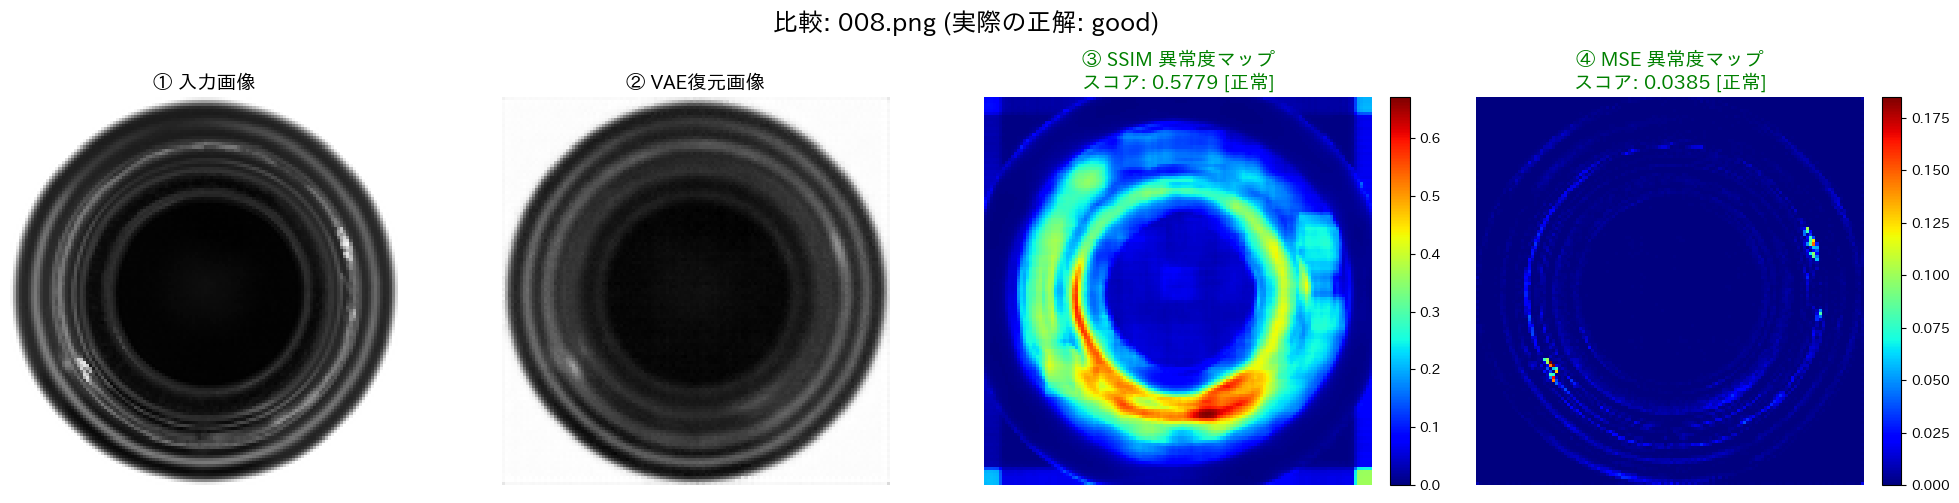

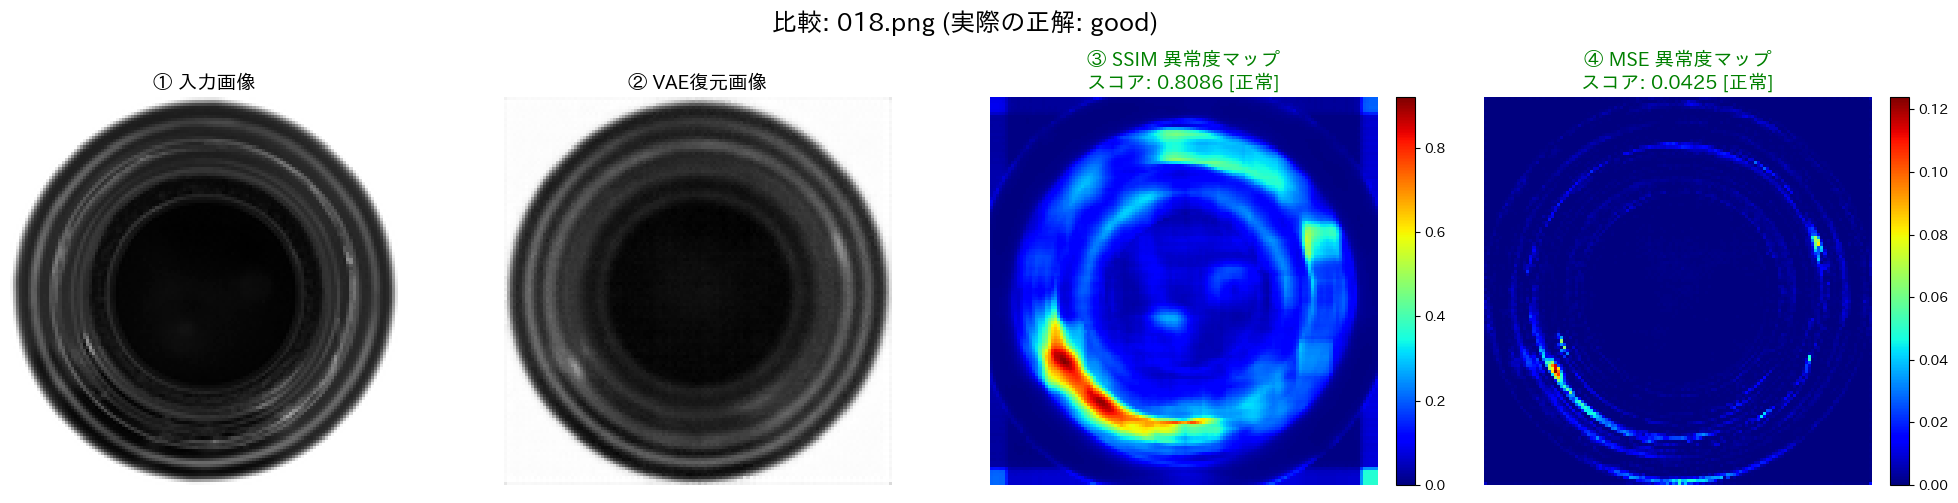

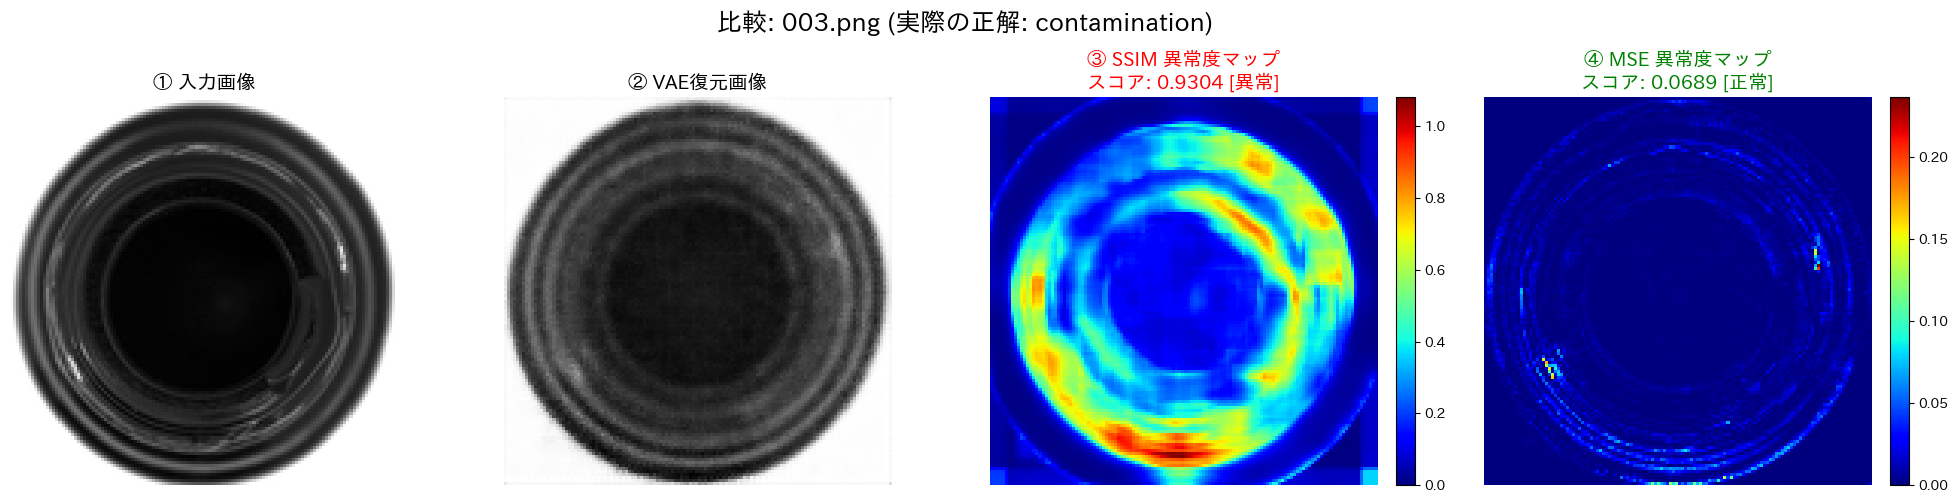

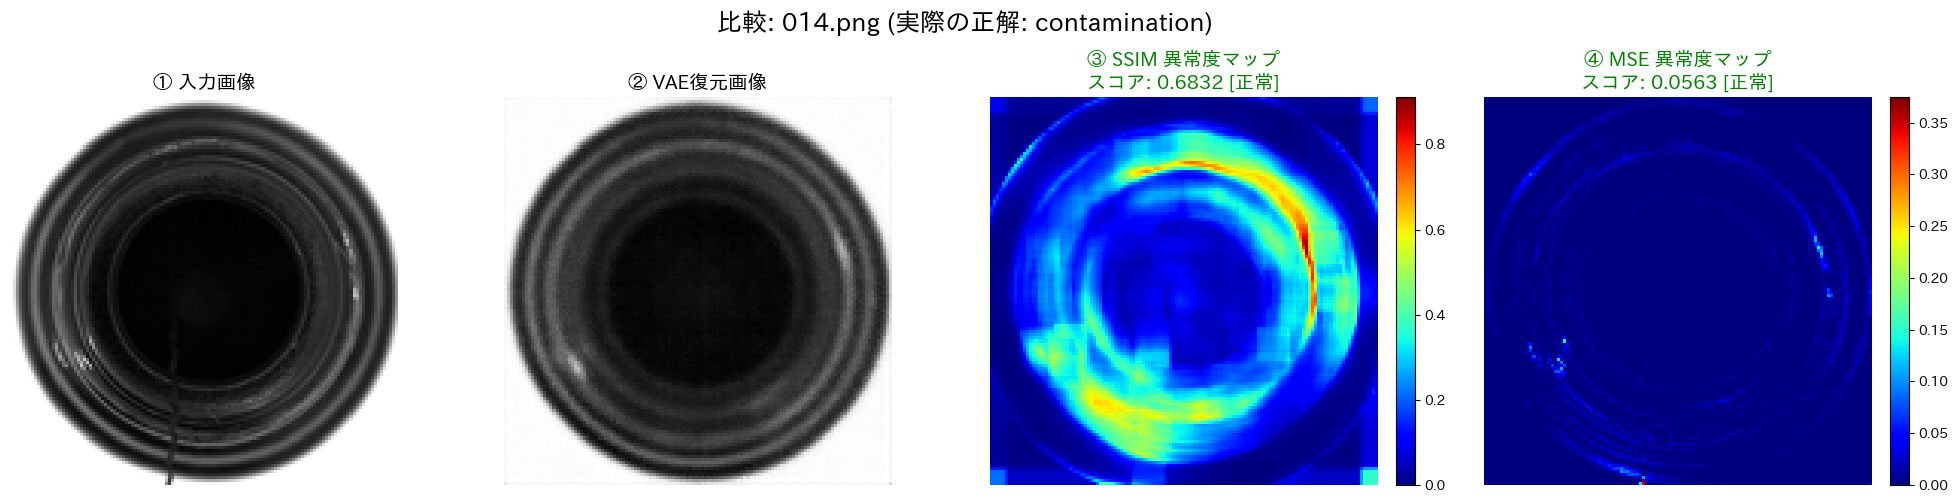

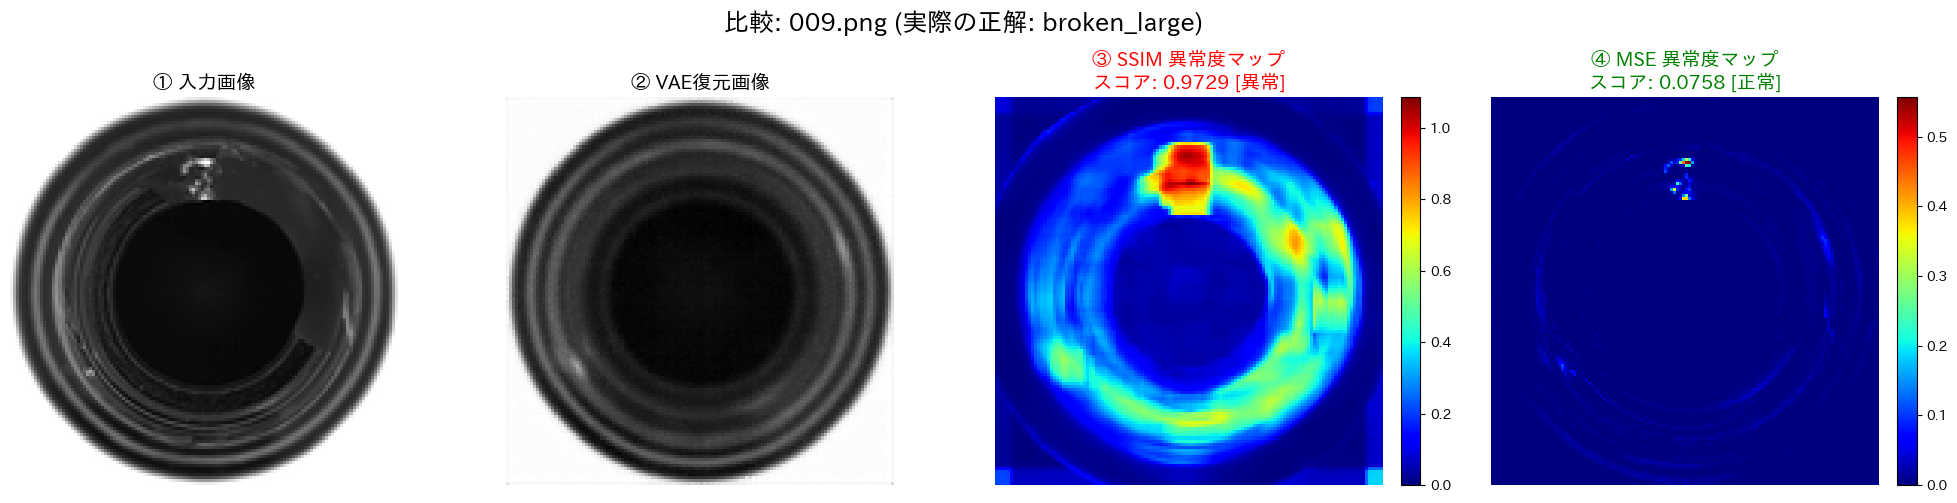


すべての検証プロセスが完了しました。


In [18]:
# =====================================================================
# 検証用コード: ハイブリッドモデル（Hybrid_CNN5_FC）100epアニーリング版
# 異常スコア: SSIM Top-K vs MSE Top-K の比較検証用
# =====================================================================
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
import random
from skimage.metrics import structural_similarity as ssim

# 文字化け対策の強制適用
import japanize_matplotlib
japanize_matplotlib.japanize()

# =====================================================================
# 1. 前処理とモデルの定義 (Hybrid_CNN5_FC版)
# =====================================================================
transform = transforms.Compose([
    transforms.CenterCrop(820),
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.LANCZOS),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

class VAE_Hybrid_CNN_FC(nn.Module):
    def __init__(self, latent_dim=64):
        super(VAE_Hybrid_CNN_FC, self).__init__()
        
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.ReLU()
        )
        
        self.encoder_fc = nn.Sequential(
            nn.Linear(256 * 4 * 4, 1024), nn.ReLU(),
            nn.Linear(1024, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU()
        )
        
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 1024), nn.ReLU(),
            nn.Linear(1024, 256 * 4 * 4), nn.ReLU()
        )
        
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h = self.encoder_conv(x)
        h = torch.flatten(h, start_dim=1)
        h = self.encoder_fc(h)
        
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        logvar = torch.clamp(logvar, min=-10.0, max=10.0)
        
        std = torch.exp(0.5 * logvar)
        z = mu + torch.randn_like(std) * std
        
        h_recon = self.decoder_fc(z)
        h_recon = h_recon.view(-1, 256, 4, 4)
        recon = self.decoder_conv(h_recon)
        
        return recon, mu, logvar

# =====================================================================
# 2. 評価と可視化の関数群 (SSIM vs MSE 比較仕様)
# =====================================================================
def evaluate_dataset(model, test_dir, device, threshold_ssim, threshold_mse, top_k=130):
    model.eval()
    y_true = []
    y_pred_ssim, scores_ssim = [], []
    y_pred_mse, scores_mse = [], []
    all_image_paths = []
    
    test_dir = Path(test_dir)
    if not test_dir.exists():
        raise FileNotFoundError(f"テストディレクトリが見つかりません: {test_dir}")

    print(f"テストデータ全件の評価を開始します... (Top-K: {top_k})")
    
    with torch.no_grad():
        for folder in test_dir.iterdir():
            if not folder.is_dir(): continue
                
            true_label = 0 if folder.name == "good" else 1
            img_paths = list(folder.glob("*.png"))
            
            for img_path in img_paths:
                img = Image.open(img_path).convert('RGB')
                input_tensor = transform(img).unsqueeze(0).to(device)
                
                recon_tensor, _, _ = model(input_tensor)
                
                input_img = input_tensor.squeeze().cpu().numpy()
                recon_img = recon_tensor.squeeze().cpu().numpy()
                
                # --- SSIMの計算 ---
                _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
                anomaly_map_ssim = 1.0 - ssim_map
                top_k_score_ssim = np.mean(np.sort(anomaly_map_ssim.flatten())[::-1][:top_k])
                
                # --- MSEの計算 ---
                anomaly_map_mse = (input_img - recon_img) ** 2
                top_k_score_mse = np.mean(np.sort(anomaly_map_mse.flatten())[::-1][:top_k])
                
                pred_ssim = 1 if top_k_score_ssim > threshold_ssim else 0
                pred_mse = 1 if top_k_score_mse > threshold_mse else 0
                
                y_true.append(true_label)
                all_image_paths.append(img_path)
                
                y_pred_ssim.append(pred_ssim)
                scores_ssim.append(top_k_score_ssim)
                
                y_pred_mse.append(pred_mse)
                scores_mse.append(top_k_score_mse)
                
    print("評価が完了しました。")
    return (np.array(y_true), np.array(y_pred_ssim), np.array(scores_ssim), 
            np.array(y_pred_mse), np.array(scores_mse), all_image_paths)

def print_and_plot_metrics(y_true, y_pred_ssim, y_pred_mse, th_ssim, th_mse, top_k):
    def calc_metrics(y_t, y_p):
        return {
            'acc': accuracy_score(y_t, y_p) * 100,
            'prec': precision_score(y_t, y_p, zero_division=0) * 100,
            'rec': recall_score(y_t, y_p, zero_division=0) * 100,
            'f1': f1_score(y_t, y_p, zero_division=0) * 100
        }
    
    m_ssim = calc_metrics(y_true, y_pred_ssim)
    m_mse = calc_metrics(y_true, y_pred_mse)
    
    print(f"\n{'='*40}")
    print(f"定量評価結果 (Top-{top_k} パッチ)")
    print(f"{'='*40}")
    print(f"[SSIM 異常検知] 閾値: {th_ssim}")
    for k, v in m_ssim.items(): print(f" - {k.upper():<5}: {v:.2f}%")
    print("-" * 40)
    print(f"[MSE 異常検知] 閾値: {th_mse}")
    for k, v in m_mse.items(): print(f" - {k.upper():<5}: {v:.2f}%")
    print(f"{'='*40}\n")
    
    # --- SSIM 混同行列（単独表示） ---
    plt.figure(figsize=(7, 6))
    cm_ssim = confusion_matrix(y_true, y_pred_ssim)
    sns.heatmap(cm_ssim, annot=True, fmt='d', cmap='Blues',
                xticklabels=['正常予測', '異常予測'], yticklabels=['実際の正常', '実際の異常'], annot_kws={"size": 16})
    title_ssim = (f"混同行列 [SSIM]\n"
                  f"正解率: {m_ssim['acc']:.1f}% | F値: {m_ssim['f1']:.1f}%\n"
                  f"適合率: {m_ssim['prec']:.1f}% | 再現率: {m_ssim['rec']:.1f}%")
    plt.title(title_ssim, fontsize=14)
    plt.xlabel('AIの予測', fontsize=12)
    plt.ylabel('実際の正解', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # --- MSE 混同行列（単独表示） ---
    plt.figure(figsize=(7, 6))
    cm_mse = confusion_matrix(y_true, y_pred_mse)
    # 色をSSIMと同じ 'Blues' に統一
    sns.heatmap(cm_mse, annot=True, fmt='d', cmap='Blues',
                xticklabels=['正常予測', '異常予測'], yticklabels=['実際の正常', '実際の異常'], annot_kws={"size": 16})
    title_mse = (f"混同行列 [MSE]\n"
                 f"正解率: {m_mse['acc']:.1f}% | F値: {m_mse['f1']:.1f}%\n"
                 f"適合率: {m_mse['prec']:.1f}% | 再現率: {m_mse['rec']:.1f}%")
    plt.title(title_mse, fontsize=14)
    plt.xlabel('AIの予測', fontsize=12)
    plt.ylabel('実際の正解', fontsize=12)
    plt.tight_layout()
    plt.show()

def plot_score_distributions(y_true, scores_ssim, scores_mse, th_ssim, th_mse, top_k):
    # ヒストグラムの共通描画関数
    def plot_single_hist(scores, th, title, xlabel):
        # 画像の大きさを少し横長で見やすいサイズ (9, 6) に設定
        plt.figure(figsize=(9, 6))
        norm_scores = scores[y_true == 0]
        anom_scores = scores[y_true == 1]
        
        # 横軸を揃えるため、ビン（棒）の区切りも0.0〜2.0の範囲で統一
        bins = np.linspace(0.0, 2.0, 70)
        
        # 色をSSIMと同じ緑と赤に統一
        sns.histplot(norm_scores, bins=bins, color='green', alpha=0.5, label='正常 (Good)', kde=False)
        sns.histplot(anom_scores, bins=bins, color='red', alpha=0.5, label='異常 (Anomaly)', kde=False)
        plt.axvline(x=th, color='blue', linestyle='--', linewidth=2, label=f'閾値 ({th})')
        
        plt.title(title, fontsize=15, fontweight='bold')
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("画像の数", fontsize=12)
        
        # ★ 縦軸と横軸のスケールを固定
        plt.xlim(0.0, 2.0)
        plt.ylim(0, 15)
        
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    # SSIMの分布（単独表示）
    plot_single_hist(scores_ssim, th_ssim, f"SSIM 異常スコア分布 (Top-{top_k})", "異常スコア (1-SSIM)")
    
    # MSEの分布（単独表示）
    plot_single_hist(scores_mse, th_mse, f"MSE 異常スコア分布 (Top-{top_k})", "異常スコア (MSE)")

def plot_anomaly_comparison(model, image_path, device, th_ssim, th_mse, top_k=160):
    model.eval()
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        recon_tensor, _, _ = model(input_tensor)
        
    input_img = input_tensor.squeeze().cpu().numpy()
    recon_img = recon_tensor.squeeze().cpu().numpy()
    
    # SSIM計算
    _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
    anomaly_map_ssim = 1.0 - ssim_map
    score_ssim = np.mean(np.sort(anomaly_map_ssim.flatten())[::-1][:top_k])
    judgement_ssim = "異常" if score_ssim > th_ssim else "正常"
    color_ssim = 'red' if score_ssim > th_ssim else 'green'
    
    # MSE計算
    anomaly_map_mse = (input_img - recon_img) ** 2
    score_mse = np.mean(np.sort(anomaly_map_mse.flatten())[::-1][:top_k])
    judgement_mse = "異常" if score_mse > th_mse else "正常"
    color_mse = 'red' if score_mse > th_mse else 'green'

    # 描画
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f"比較: {image_path.name} (実際の正解: {image_path.parent.name})", fontsize=18, fontweight='bold')
    
    axes[0].imshow(input_img, cmap='gray')
    axes[0].set_title("① 入力画像", fontsize=14)
    axes[0].axis('off')
    
    axes[1].imshow(recon_img, cmap='gray')
    axes[1].set_title("② VAE復元画像", fontsize=14)
    axes[1].axis('off')
    
    vmax_ssim = max(np.max(anomaly_map_ssim), 0.1)
    im3 = axes[2].imshow(anomaly_map_ssim, cmap='jet', vmin=0, vmax=vmax_ssim)
    axes[2].set_title(f"③ SSIM 異常度マップ\nスコア: {score_ssim:.4f} [{judgement_ssim}]", fontsize=14, color=color_ssim)
    axes[2].axis('off')
    fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)
    
    vmax_mse = max(np.max(anomaly_map_mse), 0.05)
    im4 = axes[3].imshow(anomaly_map_mse, cmap='jet', vmin=0, vmax=vmax_mse)
    axes[3].set_title(f"④ MSE 異常度マップ\nスコア: {score_mse:.4f} [{judgement_mse}]", fontsize=14, color=color_mse)
    axes[3].axis('off')
    fig.colorbar(im4, ax=axes[3], fraction=0.046, pad=0.04)
    
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

# =====================================================================
# 3. 実行ブロック
# =====================================================================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用デバイス: {device}")
    
    model = VAE_Hybrid_CNN_FC(latent_dim=64).to(device)
    MODEL_PATH = "/home/okoshi/my_GItHub/image-anomaly-detection/saved_models/vae_Hybrid_CNN5_FC_Annealing_ep100_beta50_128.pth"
    
    if not Path(MODEL_PATH).exists():
        raise FileNotFoundError(f"重みファイルが見つかりません: {MODEL_PATH}")
    
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print(f"モデルの重みを読み込みました。\n")

    TEST_DIR = "/home/okoshi/my_GItHub/image-anomaly-detection/data/bottle/test"
    
    # -------------------------------------------------------------
    # ★ パラメータ設定 ★
    # -------------------------------------------------------------
    TOP_K = 160
    THRESHOLD_SSIM = 0.825
    THRESHOLD_MSE = 0.08  # 要調整: MSE用の閾値
    
    # 評価実行
    (y_true, y_pred_ssim, scores_ssim, 
     y_pred_mse, scores_mse, all_image_paths) = evaluate_dataset(
         model, TEST_DIR, device, THRESHOLD_SSIM, THRESHOLD_MSE, top_k=TOP_K)
    
    # 定量評価と混同行列（4指標追加、単独画像化、色統一）
    print_and_plot_metrics(y_true, y_pred_ssim, y_pred_mse, THRESHOLD_SSIM, THRESHOLD_MSE, TOP_K)
    
    # スコア分布比較（単独画像化、色統一）
    plot_score_distributions(y_true, scores_ssim, scores_mse, THRESHOLD_SSIM, THRESHOLD_MSE, TOP_K)
    
    print("\n--- ランダムに数枚抽出し、SSIMとMSEのヒートマップを比較します ---")
    normal_paths = [p for t, p in zip(y_true, all_image_paths) if t == 0]
    anomaly_paths = [p for t, p in zip(y_true, all_image_paths) if t == 1]
    
    sample_paths = []
    if normal_paths: sample_paths.extend(random.sample(normal_paths, min(2, len(normal_paths))))
    if anomaly_paths: sample_paths.extend(random.sample(anomaly_paths, min(3, len(anomaly_paths))))
    
    for img_path in sample_paths:
        plot_anomaly_comparison(model, img_path, device, THRESHOLD_SSIM, THRESHOLD_MSE, top_k=TOP_K)

    print("\nすべての検証プロセスが完了しました。")

使用デバイス: cuda
モデルの重みを読み込みました。

テストデータ全件の評価を開始します... (Top-K: 160)
評価が完了しました。

定量評価結果 (Top-160 パッチ)
[SSIM 異常検知] 閾値: 0.825
 - ACC  : 92.77%
 - PREC : 95.24%
 - REC  : 95.24%
 - F1   : 95.24%
----------------------------------------
[MSE 異常検知] 閾値: 0.08
 - ACC  : 78.31%
 - PREC : 94.12%
 - REC  : 76.19%
 - F1   : 84.21%



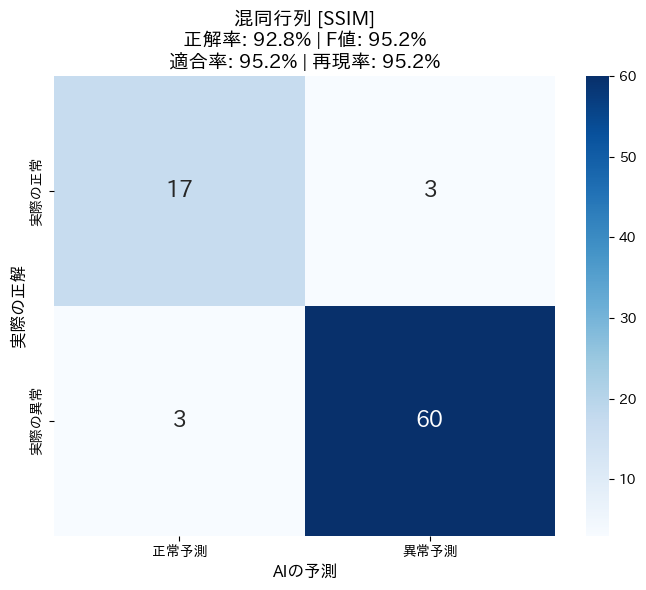

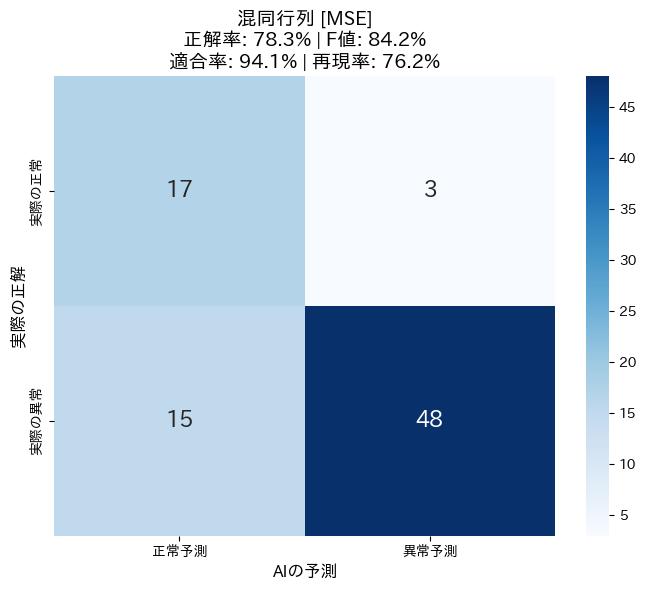

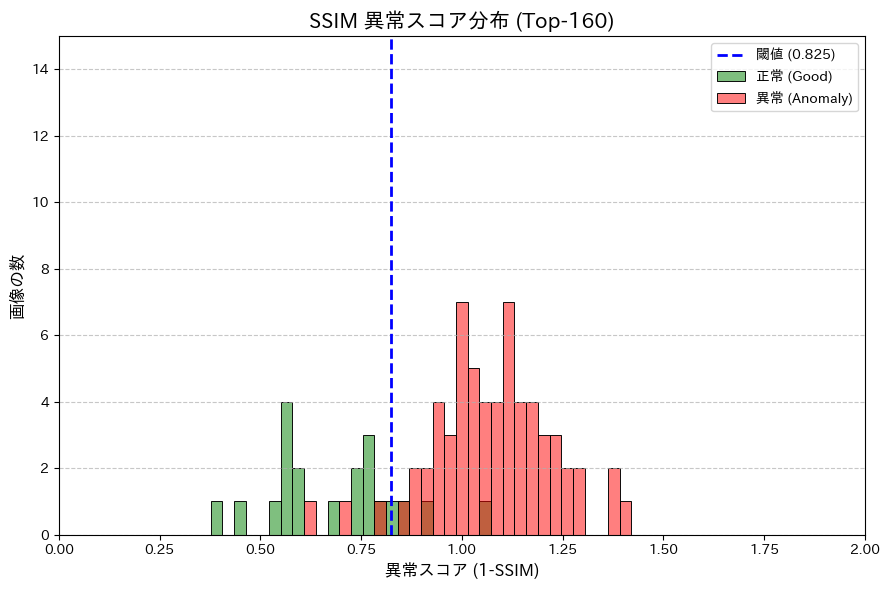

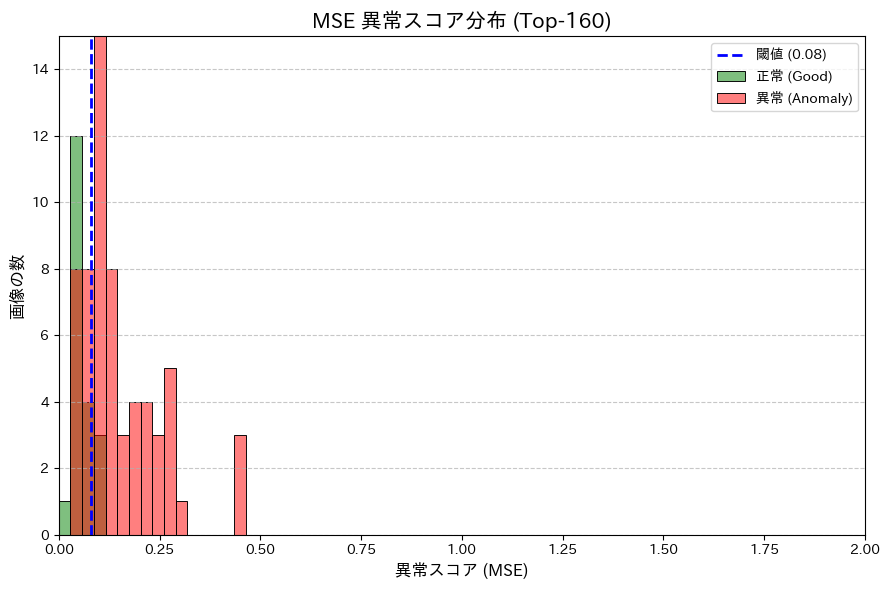


--- ランダムに数枚抽出し、SSIMとMSEのヒートマップを比較します ---


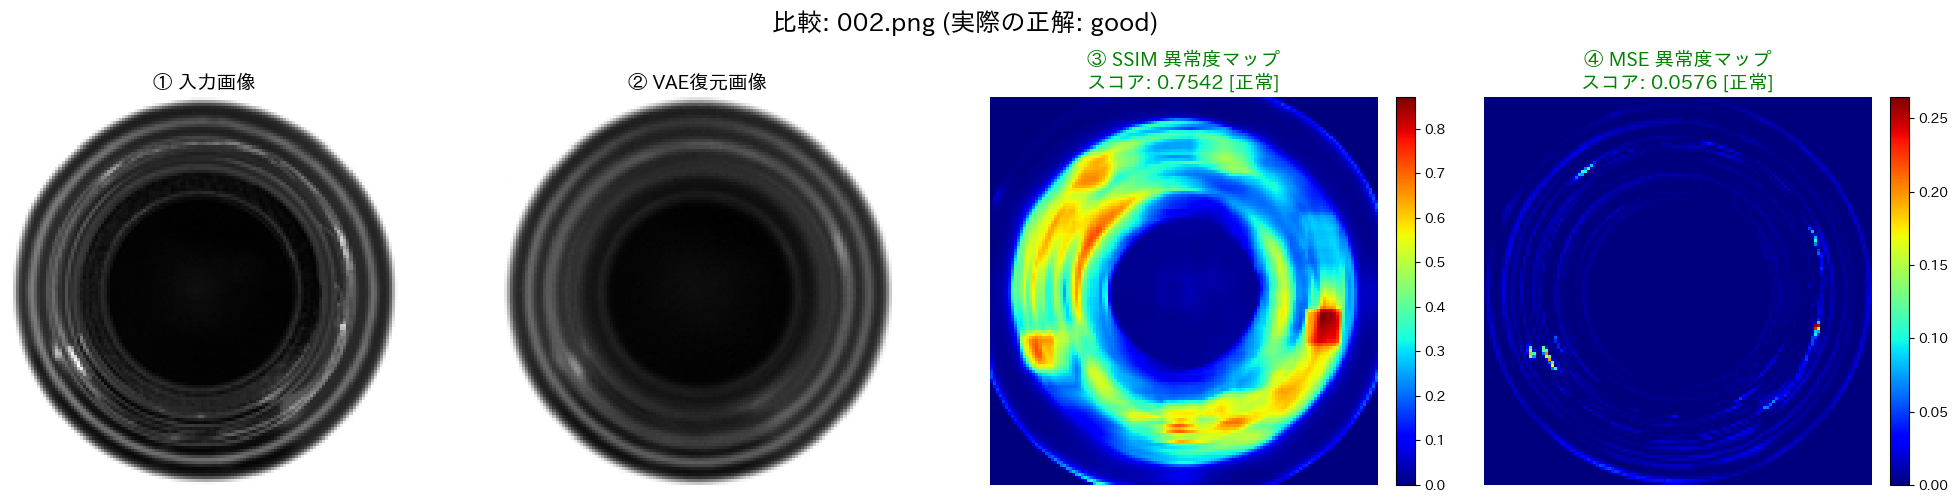

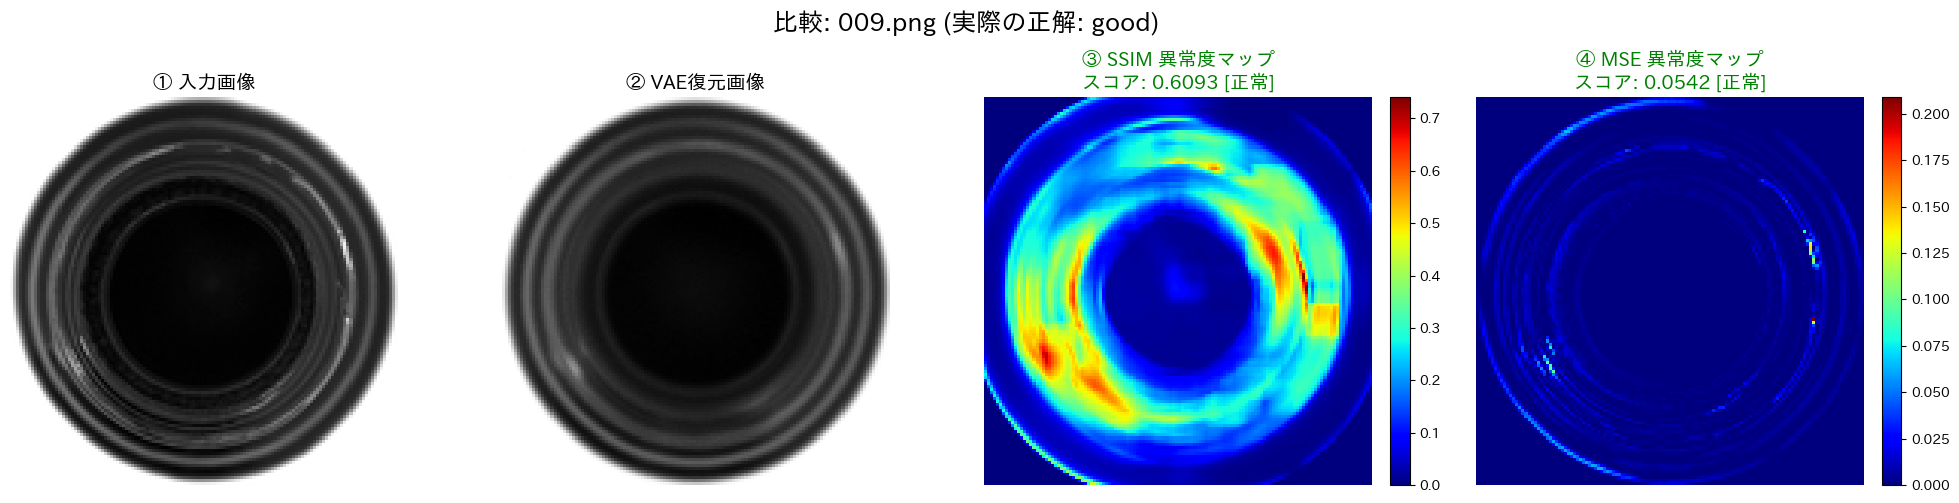

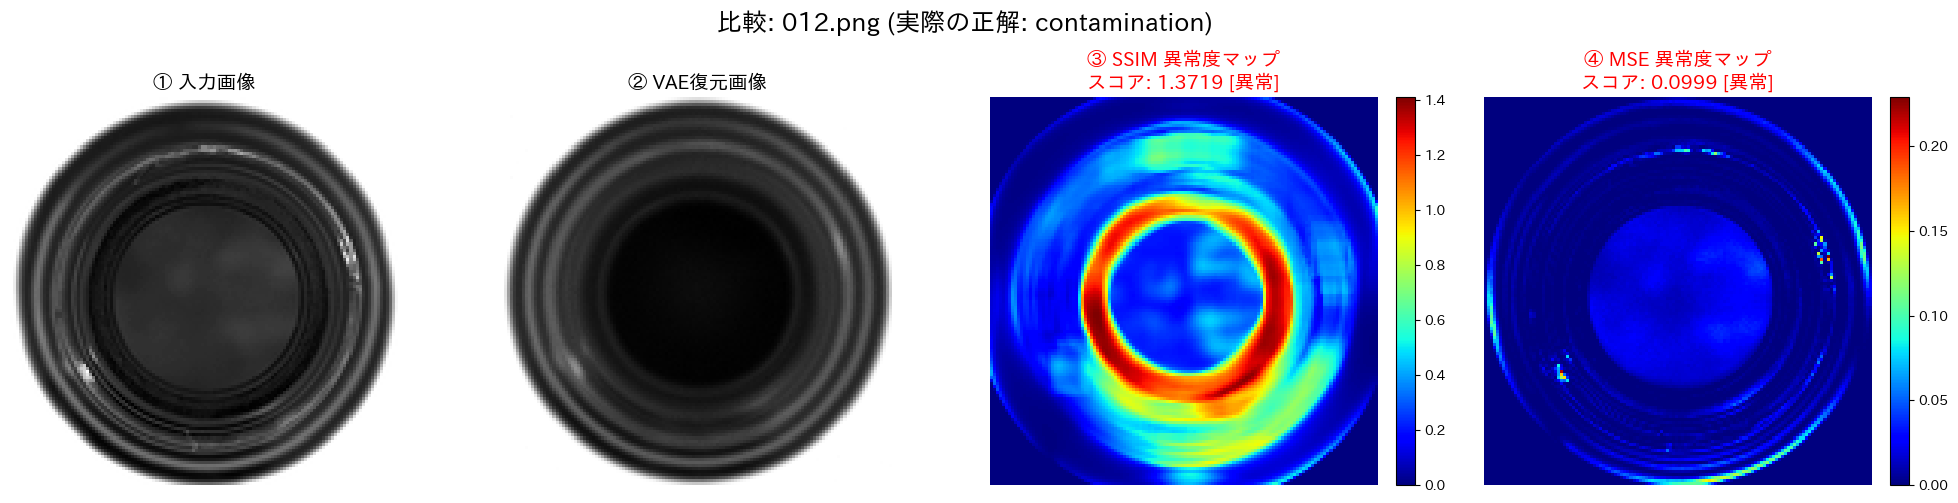

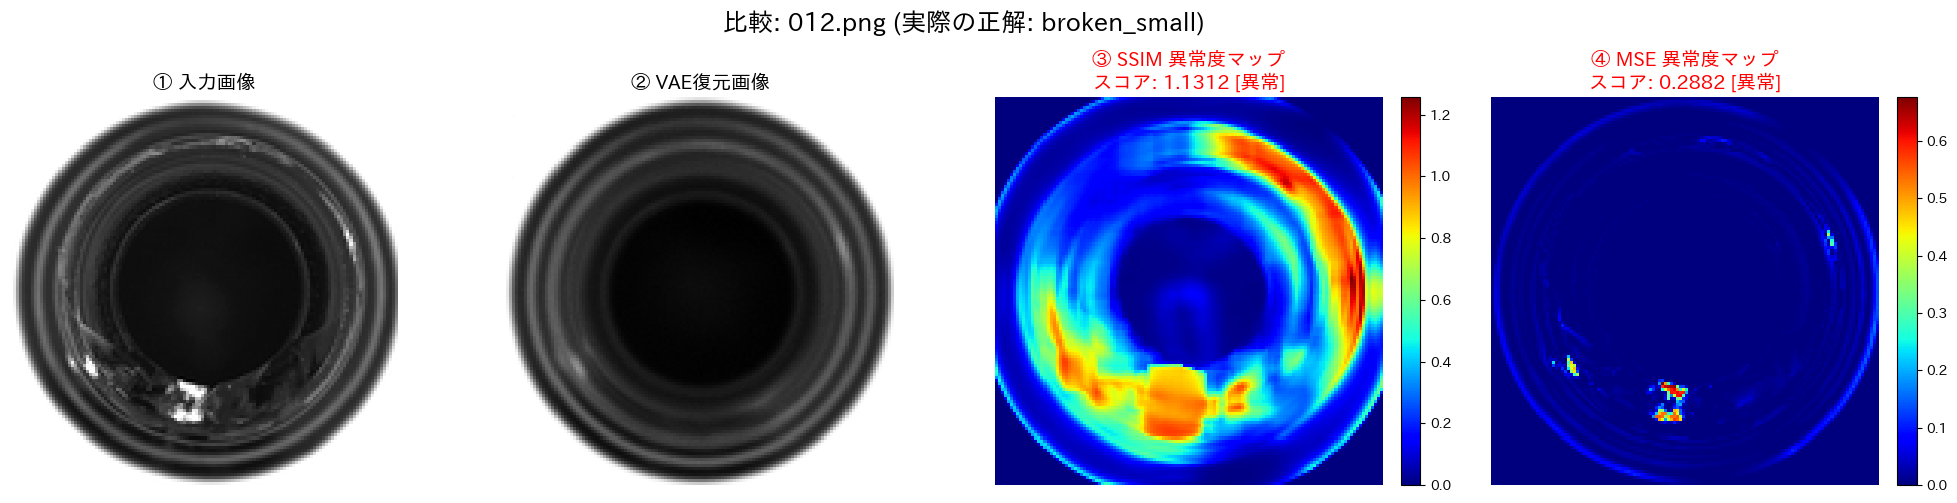

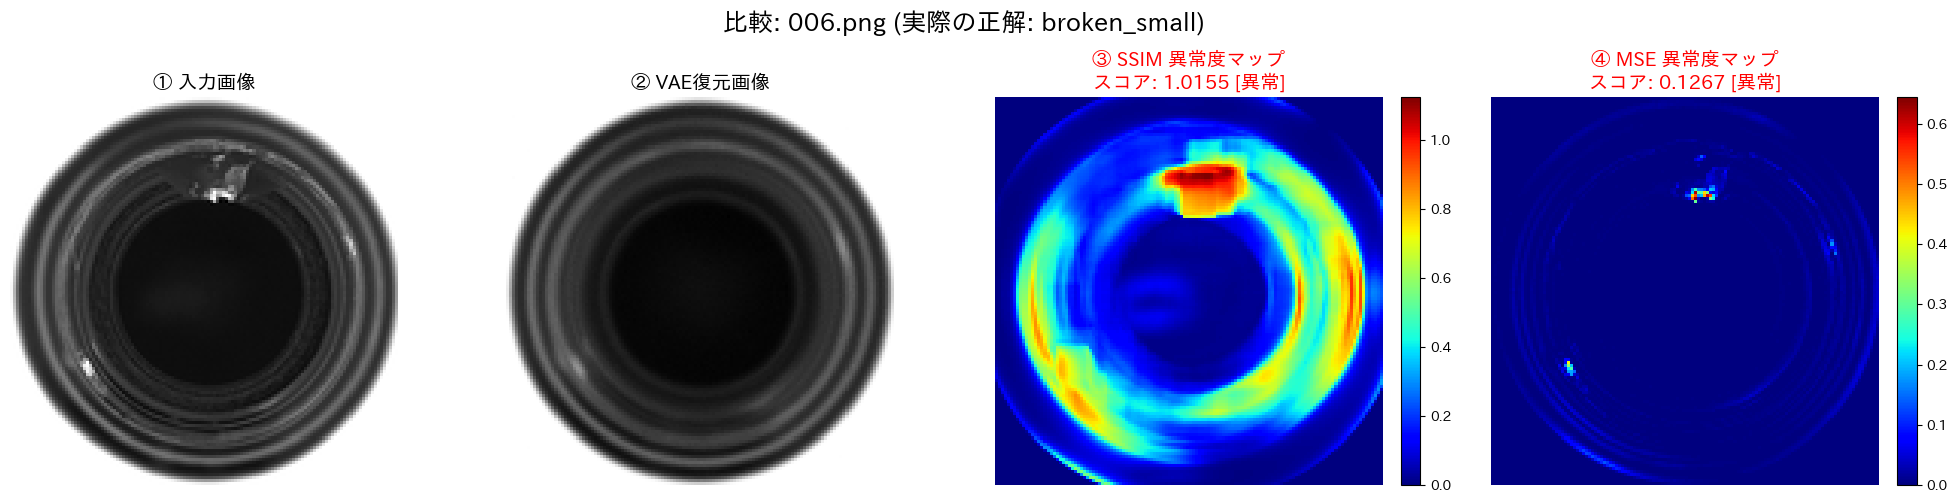


すべての検証プロセスが完了しました。


In [17]:
# =====================================================================
# 検証用コード: 完全結合モデル（FC_Only）版
# 異常スコア: SSIM Top-K vs MSE Top-K の比較検証用
# =====================================================================
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
import random
from skimage.metrics import structural_similarity as ssim

# 文字化け対策の強制適用
import japanize_matplotlib
japanize_matplotlib.japanize()

# =====================================================================
# 1. 前処理とモデルの定義 (FC_Only版)
# =====================================================================
transform = transforms.Compose([
    transforms.CenterCrop(820),
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.LANCZOS),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

class VAE_FC_Only(nn.Module):
    def __init__(self, latent_dim=64):
        super(VAE_FC_Only, self).__init__()
        
        # 128x128ピクセル = 16384次元の一次元データとして処理
        self.encoder = nn.Sequential(
            nn.Linear(128 * 128, 1024), nn.ReLU(),
            nn.Linear(1024, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU()
        )
        
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 1024), nn.ReLU(),
            nn.Linear(1024, 128 * 128), nn.Sigmoid()
        )

    def forward(self, x):
        # 2次元の画像データを1次元に平坦化
        x_flat = torch.flatten(x, start_dim=1)
        
        h = self.encoder(x_flat)
        
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        logvar = torch.clamp(logvar, min=-10.0, max=10.0)
        
        std = torch.exp(0.5 * logvar)
        z = mu + torch.randn_like(std) * std
        
        recon_flat = self.decoder(z)
        # 1次元の出力を、元の画像サイズ (バッチサイズ, 1チャンネル, 128, 128) に戻す
        recon = recon_flat.view(-1, 1, 128, 128)
        
        return recon, mu, logvar

# =====================================================================
# 2. 評価と可視化の関数群 (SSIM vs MSE 比較仕様)
# =====================================================================
def evaluate_dataset(model, test_dir, device, threshold_ssim, threshold_mse, top_k=130):
    model.eval()
    y_true = []
    y_pred_ssim, scores_ssim = [], []
    y_pred_mse, scores_mse = [], []
    all_image_paths = []
    
    test_dir = Path(test_dir)
    if not test_dir.exists():
        raise FileNotFoundError(f"テストディレクトリが見つかりません: {test_dir}")

    print(f"テストデータ全件の評価を開始します... (Top-K: {top_k})")
    
    with torch.no_grad():
        for folder in test_dir.iterdir():
            if not folder.is_dir(): continue
                
            true_label = 0 if folder.name == "good" else 1
            img_paths = list(folder.glob("*.png"))
            
            for img_path in img_paths:
                img = Image.open(img_path).convert('RGB')
                input_tensor = transform(img).unsqueeze(0).to(device)
                
                recon_tensor, _, _ = model(input_tensor)
                
                input_img = input_tensor.squeeze().cpu().numpy()
                recon_img = recon_tensor.squeeze().cpu().numpy()
                
                # --- SSIMの計算 ---
                _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
                anomaly_map_ssim = 1.0 - ssim_map
                top_k_score_ssim = np.mean(np.sort(anomaly_map_ssim.flatten())[::-1][:top_k])
                
                # --- MSEの計算 ---
                anomaly_map_mse = (input_img - recon_img) ** 2
                top_k_score_mse = np.mean(np.sort(anomaly_map_mse.flatten())[::-1][:top_k])
                
                pred_ssim = 1 if top_k_score_ssim > threshold_ssim else 0
                pred_mse = 1 if top_k_score_mse > threshold_mse else 0
                
                y_true.append(true_label)
                all_image_paths.append(img_path)
                
                y_pred_ssim.append(pred_ssim)
                scores_ssim.append(top_k_score_ssim)
                
                y_pred_mse.append(pred_mse)
                scores_mse.append(top_k_score_mse)
                
    print("評価が完了しました。")
    return (np.array(y_true), np.array(y_pred_ssim), np.array(scores_ssim), 
            np.array(y_pred_mse), np.array(scores_mse), all_image_paths)

def print_and_plot_metrics(y_true, y_pred_ssim, y_pred_mse, th_ssim, th_mse, top_k):
    def calc_metrics(y_t, y_p):
        return {
            'acc': accuracy_score(y_t, y_p) * 100,
            'prec': precision_score(y_t, y_p, zero_division=0) * 100,
            'rec': recall_score(y_t, y_p, zero_division=0) * 100,
            'f1': f1_score(y_t, y_p, zero_division=0) * 100
        }
    
    m_ssim = calc_metrics(y_true, y_pred_ssim)
    m_mse = calc_metrics(y_true, y_pred_mse)
    
    print(f"\n{'='*40}")
    print(f"定量評価結果 (Top-{top_k} パッチ)")
    print(f"{'='*40}")
    print(f"[SSIM 異常検知] 閾値: {th_ssim}")
    for k, v in m_ssim.items(): print(f" - {k.upper():<5}: {v:.2f}%")
    print("-" * 40)
    print(f"[MSE 異常検知] 閾値: {th_mse}")
    for k, v in m_mse.items(): print(f" - {k.upper():<5}: {v:.2f}%")
    print(f"{'='*40}\n")
    
    # --- SSIM 混同行列（単独表示） ---
    plt.figure(figsize=(7, 6))
    cm_ssim = confusion_matrix(y_true, y_pred_ssim)
    sns.heatmap(cm_ssim, annot=True, fmt='d', cmap='Blues',
                xticklabels=['正常予測', '異常予測'], yticklabels=['実際の正常', '実際の異常'], annot_kws={"size": 16})
    title_ssim = (f"混同行列 [SSIM]\n"
                  f"正解率: {m_ssim['acc']:.1f}% | F値: {m_ssim['f1']:.1f}%\n"
                  f"適合率: {m_ssim['prec']:.1f}% | 再現率: {m_ssim['rec']:.1f}%")
    plt.title(title_ssim, fontsize=14)
    plt.xlabel('AIの予測', fontsize=12)
    plt.ylabel('実際の正解', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # --- MSE 混同行列（単独表示） ---
    plt.figure(figsize=(7, 6))
    cm_mse = confusion_matrix(y_true, y_pred_mse)
    # 色をSSIMと同じ 'Blues' に統一
    sns.heatmap(cm_mse, annot=True, fmt='d', cmap='Blues',
                xticklabels=['正常予測', '異常予測'], yticklabels=['実際の正常', '実際の異常'], annot_kws={"size": 16})
    title_mse = (f"混同行列 [MSE]\n"
                 f"正解率: {m_mse['acc']:.1f}% | F値: {m_mse['f1']:.1f}%\n"
                 f"適合率: {m_mse['prec']:.1f}% | 再現率: {m_mse['rec']:.1f}%")
    plt.title(title_mse, fontsize=14)
    plt.xlabel('AIの予測', fontsize=12)
    plt.ylabel('実際の正解', fontsize=12)
    plt.tight_layout()
    plt.show()

def plot_score_distributions(y_true, scores_ssim, scores_mse, th_ssim, th_mse, top_k):
    # ヒストグラムの共通描画関数
    def plot_single_hist(scores, th, title, xlabel):
        # 画像の大きさを少し横長で見やすいサイズ (9, 6) に設定
        plt.figure(figsize=(9, 6))
        norm_scores = scores[y_true == 0]
        anom_scores = scores[y_true == 1]
        
        # 横軸を揃えるため、ビン（棒）の区切りも0.0〜2.0の範囲で統一
        bins = np.linspace(0.0, 2.0, 70)
        
        # 色をSSIMと同じ緑と赤に統一
        sns.histplot(norm_scores, bins=bins, color='green', alpha=0.5, label='正常 (Good)', kde=False)
        sns.histplot(anom_scores, bins=bins, color='red', alpha=0.5, label='異常 (Anomaly)', kde=False)
        plt.axvline(x=th, color='blue', linestyle='--', linewidth=2, label=f'閾値 ({th})')
        
        plt.title(title, fontsize=15, fontweight='bold')
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("画像の数", fontsize=12)
        
        # ★ 縦軸と横軸のスケールを固定
        plt.xlim(0.0, 2.0)
        plt.ylim(0, 15)
        
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    # SSIMの分布（単独表示）
    plot_single_hist(scores_ssim, th_ssim, f"SSIM 異常スコア分布 (Top-{top_k})", "異常スコア (1-SSIM)")
    
    # MSEの分布（単独表示）
    plot_single_hist(scores_mse, th_mse, f"MSE 異常スコア分布 (Top-{top_k})", "異常スコア (MSE)")

def plot_anomaly_comparison(model, image_path, device, th_ssim, th_mse, top_k=160):
    model.eval()
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        recon_tensor, _, _ = model(input_tensor)
        
    input_img = input_tensor.squeeze().cpu().numpy()
    recon_img = recon_tensor.squeeze().cpu().numpy()
    
    # SSIM計算
    _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
    anomaly_map_ssim = 1.0 - ssim_map
    score_ssim = np.mean(np.sort(anomaly_map_ssim.flatten())[::-1][:top_k])
    judgement_ssim = "異常" if score_ssim > th_ssim else "正常"
    color_ssim = 'red' if score_ssim > th_ssim else 'green'
    
    # MSE計算
    anomaly_map_mse = (input_img - recon_img) ** 2
    score_mse = np.mean(np.sort(anomaly_map_mse.flatten())[::-1][:top_k])
    judgement_mse = "異常" if score_mse > th_mse else "正常"
    color_mse = 'red' if score_mse > th_mse else 'green'

    # 描画
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f"比較: {image_path.name} (実際の正解: {image_path.parent.name})", fontsize=18, fontweight='bold')
    
    axes[0].imshow(input_img, cmap='gray')
    axes[0].set_title("① 入力画像", fontsize=14)
    axes[0].axis('off')
    
    axes[1].imshow(recon_img, cmap='gray')
    axes[1].set_title("② VAE復元画像", fontsize=14)
    axes[1].axis('off')
    
    vmax_ssim = max(np.max(anomaly_map_ssim), 0.1)
    im3 = axes[2].imshow(anomaly_map_ssim, cmap='jet', vmin=0, vmax=vmax_ssim)
    axes[2].set_title(f"③ SSIM 異常度マップ\nスコア: {score_ssim:.4f} [{judgement_ssim}]", fontsize=14, color=color_ssim)
    axes[2].axis('off')
    fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)
    
    vmax_mse = max(np.max(anomaly_map_mse), 0.05)
    im4 = axes[3].imshow(anomaly_map_mse, cmap='jet', vmin=0, vmax=vmax_mse)
    axes[3].set_title(f"④ MSE 異常度マップ\nスコア: {score_mse:.4f} [{judgement_mse}]", fontsize=14, color=color_mse)
    axes[3].axis('off')
    fig.colorbar(im4, ax=axes[3], fraction=0.046, pad=0.04)
    
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

# =====================================================================
# 3. 実行ブロック
# =====================================================================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用デバイス: {device}")
    
    model = VAE_FC_Only(latent_dim=64).to(device)
    
    MODEL_PATH = r"/home/okoshi/my_GItHub/image-anomaly-detection/saved_models/vae_FC_Only_Annealing_ep100_beta50_128.pth"
    
    if not Path(MODEL_PATH).exists():
        raise FileNotFoundError(f"重みファイルが見つかりません: {MODEL_PATH}")
    
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print(f"モデルの重みを読み込みました。\n")
    
    TEST_DIR = r"/home/okoshi/my_GItHub/image-anomaly-detection/data/bottle/test"
    
    # -------------------------------------------------------------
    # ★ パラメータ設定 ★
    # -------------------------------------------------------------
    TOP_K = 160
    THRESHOLD_SSIM = 0.825
    THRESHOLD_MSE = 0.08  # ヒストグラムの分布を見て適宜微調整してください
    
    # 評価実行
    (y_true, y_pred_ssim, scores_ssim, 
     y_pred_mse, scores_mse, all_image_paths) = evaluate_dataset(
         model, TEST_DIR, device, THRESHOLD_SSIM, THRESHOLD_MSE, top_k=TOP_K)
    
    # 定量評価と混同行列（4指標追加、単独画像化、色統一）
    print_and_plot_metrics(y_true, y_pred_ssim, y_pred_mse, THRESHOLD_SSIM, THRESHOLD_MSE, TOP_K)
    
    # スコア分布比較（単独画像化、色統一）
    plot_score_distributions(y_true, scores_ssim, scores_mse, THRESHOLD_SSIM, THRESHOLD_MSE, TOP_K)
    
    print("\n--- ランダムに数枚抽出し、SSIMとMSEのヒートマップを比較します ---")
    normal_paths = [p for t, p in zip(y_true, all_image_paths) if t == 0]
    anomaly_paths = [p for t, p in zip(y_true, all_image_paths) if t == 1]
    
    sample_paths = []
    if normal_paths: sample_paths.extend(random.sample(normal_paths, min(2, len(normal_paths))))
    if anomaly_paths: sample_paths.extend(random.sample(anomaly_paths, min(3, len(anomaly_paths))))
    
    for img_path in sample_paths:
        plot_anomaly_comparison(model, img_path, device, THRESHOLD_SSIM, THRESHOLD_MSE, top_k=TOP_K)

    print("\nすべての検証プロセスが完了しました。")